# Draft Exploratory Data Analysis
This notebook explores the cleaned integrated dataset *cleaned_bulls_data.csv* to answer the project research questions without performing linear regression. We focus on draft pick impact, rookie playing time, player performance metrics, and Bulls season outcomes from 2000 to 2025.

In [4]:
# Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

data_path = '../data/processed/cleaned_bulls_data.csv'
df = pd.read_csv(data_path)

print('Loaded dataset with rows:', len(df), 'and columns:', len(df.columns))
df.head()

Loaded dataset with rows: 39 and columns: 51


,Season,Team,W,L,W/L%,Finish,SRS,Pace,Rel Pace,ORtg,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,ROY
0,2025,Chicago Bulls,27,38,0.415,4,-4.08,101.7,2.3,113.2,...,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,NaN,0
1,2024,Chicago Bulls,39,43,0.476,5,-1.83,102.8,4.0,114.1,...,2.8,3.5,1.0,0.4,0.9,0.9,1.6,8.6,ROY-7,7
2,2022,Chicago Bulls,40,42,0.488,3,1.37,98.5,-0.6,113.5,...,0.7,1.0,0.6,0.3,0.1,0.2,0.6,2.2,NaN,0
3,2021,Chicago Bulls*,46,36,0.561,2,-0.38,98.3,0.1,113.2,...,3.7,4.6,1.4,0.9,0.6,1.4,1.8,9.2,NaN,0
4,2020,Chicago Bulls,31,41,0.431,3,-0.94,99.0,-0.2,111.1,...,3.7,4.6,1.4,0.9,0.6,1.4,1.8,9.2,NaN,0


## Dataset overview
We are using the cleaned integrated Bulls dataset. Each row represents a Chicago Bulls draft pick and the corresponding season outcome for the team in the year the player was drafted. The dataset includes team season results, player draft information, rookie season statistics, and some team advanced metrics.

In [5]:
# Basic dataset structure and summary
print('Column names:', df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values by column:')
print(df.isna().sum().sort_values(ascending=False).head(20))
print()
print('Numeric summary for key columns:')
print(df[['W/L%', 'Pk', 'G', 'PTS', 'TRB', 'AST', 'FG%']].describe())

Column names: ['Season', 'Team', 'W', 'L', 'W/L%', 'Finish', 'SRS', 'Pace', 'Rel Pace', 'ORtg', 'Rel ORtg', 'DRtg', 'Rel DRtg', 'Playoffs', 'Coaches', 'Top WS', 'Year', 'Lg', 'Rd', 'Pk', 'Player', 'College', 'Age', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Awards', 'ROY']

Data types:
Season        int64
Team         object
W             int64
L             int64
W/L%        float64
Finish        int64
SRS         float64
Pace        float64
Rel Pace    float64
ORtg        float64
Rel ORtg    float64
DRtg        float64
Rel DRtg    float64
Playoffs     object
Coaches      object
Top WS       object
Year          int64
Lg           object
Rd            int64
Pk            int64
Player       object
College      object
Age         float64
Pos          object
G           float64
GS          float64
MP          float64
FG          float64
FGA         float64
F

## Data quality checks
The dataset is already cleaned, but we confirm there are no missing values in core numeric fields used for analysis. Some non-numeric fields like **College** and **Awards** are partially empty, which is acceptable for this exploratory analysis.

In [6]:
# Check missing values and season coverage
missing = df.isna().sum()
print(missing[missing > 0])

print('Season range:', df['Season'].min(), 'to', df['Season'].max())
print('Unique draft picks:', df['Pk'].nunique())
print('Player count:', df['Player'].nunique())

print(df['Playoffs'].value_counts(dropna=False))

College     6
Awards     33
dtype: int64
Season range: 2000 to 2025
Unique draft picks: 28
Player count: 39
Playoffs
Missed Playoffs           26
Lost E. Conf. 1st Rnd.    11
Lost E. Conf. Semis        2
Name: count, dtype: int64


## Research question 1: How does draft pick rank relate to Bulls season success?
We examine whether earlier draft positions tend to coincide with higher Bulls win percentages in the drafted season.

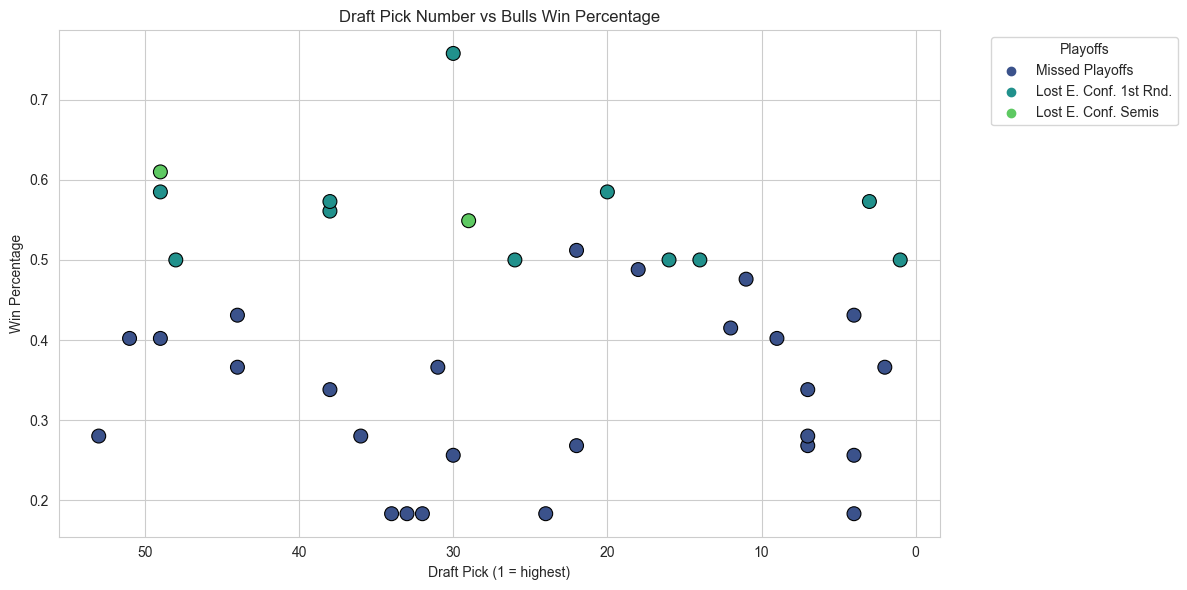

Correlation between draft pick and win percentage: 0.107
  Pick Tier      W/L%
0    Top 10  0.359700
1     11-20  0.494000
2     21-40  0.379533
3       41+  0.447000


C:\Users\12248\AppData\Local\Temp\ipykernel_12824\2910436696.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_tier = df.groupby('Pick Tier')['W/L%'].mean().reset_index()


In [7]:
# Scatter plot: draft pick vs team win percentage
plt.figure()
sns.scatterplot(data=df, x='Pk', y='W/L%', hue='Playoffs', palette='viridis', edgecolor='black', s=100)
plt.gca().invert_xaxis()
plt.title('Draft Pick Number vs Bulls Win Percentage')
plt.xlabel('Draft Pick (1 = highest)')
plt.ylabel('Win Percentage')
plt.legend(title='Playoffs', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

corr_pick = df['Pk'].corr(df['W/L%'])
print('Correlation between draft pick and win percentage:', round(corr_pick, 3))

pick_bins = [0, 10, 20, 40, 60]
labels = ['Top 10', '11-20', '21-40', '41+']
df['Pick Tier'] = pd.cut(df['Pk'], bins=pick_bins, labels=labels, right=True)
avg_by_tier = df.groupby('Pick Tier')['W/L%'].mean().reset_index()
print(avg_by_tier)

### Insight
A negative correlation would suggest better team outcomes when the Bulls selected earlier draft picks. The scatter plot and grouped averages help show whether the Bulls tended to perform better in seasons when they had higher draft positioning.

C:\Users\12248\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


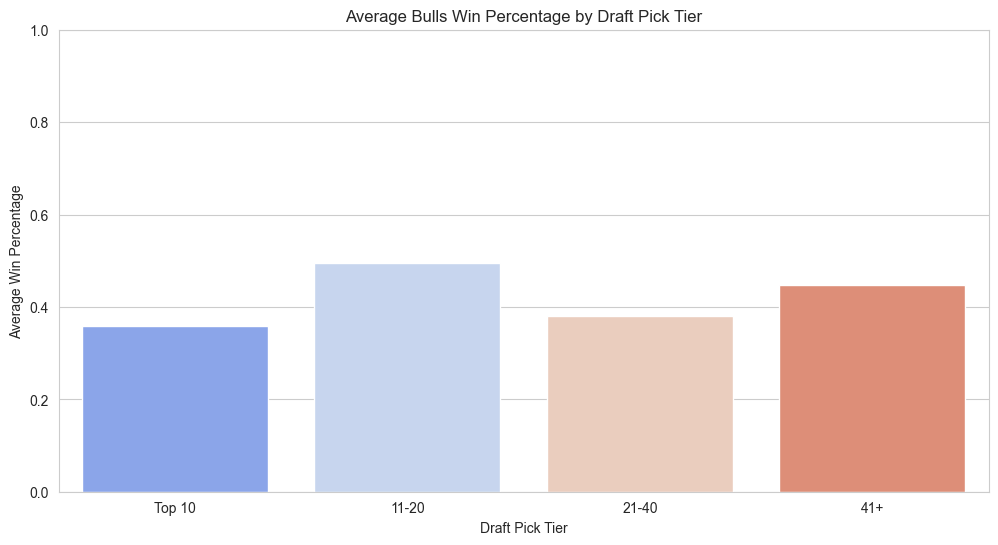

In [8]:
# Display average win percentage by draft pick tier
plt.figure()
sns.barplot(data=avg_by_tier, x='Pick Tier', y='W/L%', palette='coolwarm')
plt.title('Average Bulls Win Percentage by Draft Pick Tier')
plt.xlabel('Draft Pick Tier')
plt.ylabel('Average Win Percentage')
plt.ylim(0, 1)
plt.show()

## Research question 2: Does rookie playing time relate to team success?
We analyze whether rookies who appeared in more games for the Bulls are associated with stronger season performance.

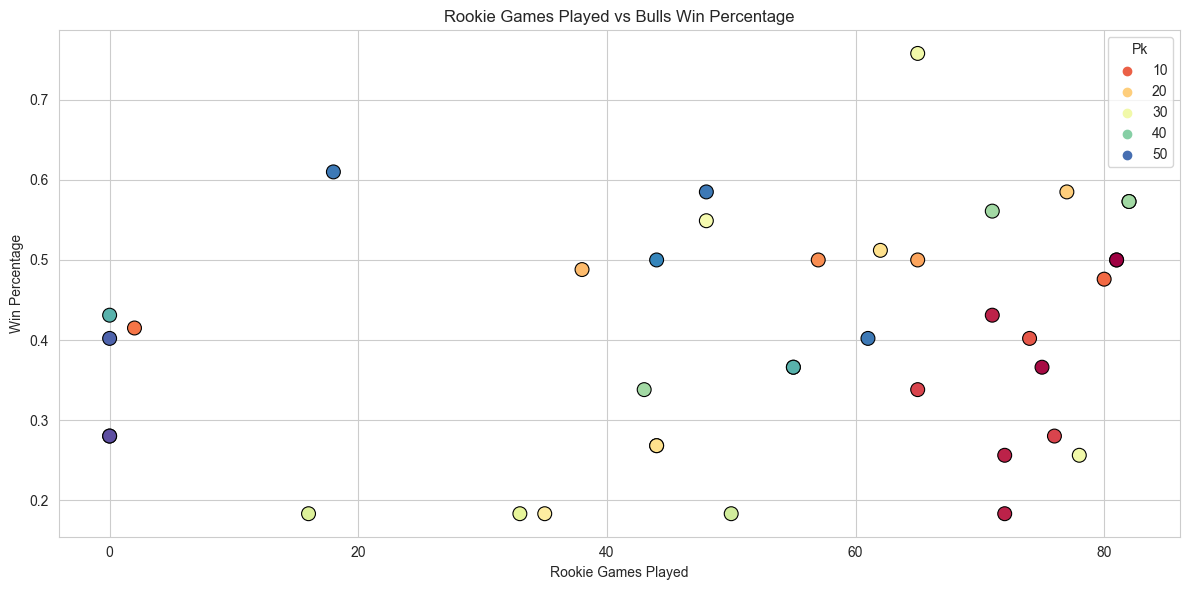

Correlation between rookie games and win percentage: 0.255


In [9]:
# Scatter plot: rookie games played vs win percentage
plt.figure()
sns.scatterplot(data=df, x='G', y='W/L%', hue='Pk', palette='Spectral', edgecolor='black', s=100)
plt.title('Rookie Games Played vs Bulls Win Percentage')
plt.xlabel('Rookie Games Played')
plt.ylabel('Win Percentage')
plt.tight_layout()
plt.show()

print('Correlation between rookie games and win percentage:', round(df['G'].corr(df['W/L%']), 3))

### Insight
This plot reveals whether the Bulls followed rookie-heavy rotations in stronger seasons. We also check correlation to quantify the strength of the relationship between rookie availability and team success.

  Games Group      W/L%
0        0-20  0.371571
1       21-40  0.284667
2       41-60  0.392300
3       61-82  0.444842


C:\Users\12248\AppData\Local\Temp\ipykernel_12824\827054289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_games = df.groupby('Games Group')['W/L%'].mean().reset_index()
C:\Users\12248\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


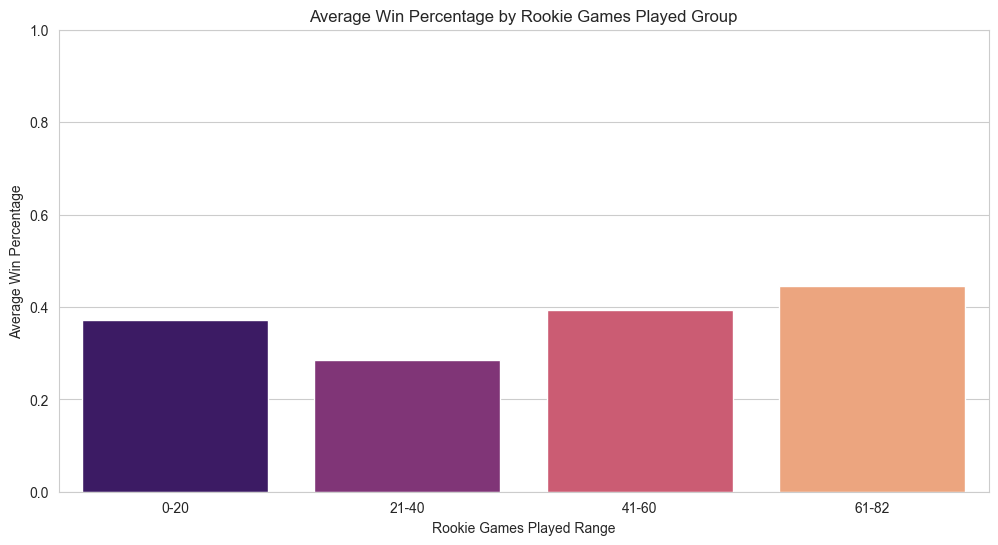

In [10]:
# Compare average win% by rookie games played buckets
df['Games Group'] = pd.cut(df['G'], bins=[-1, 20, 40, 60, 82], labels=['0-20', '21-40', '41-60', '61-82'])
avg_games = df.groupby('Games Group')['W/L%'].mean().reset_index()
print(avg_games)
plt.figure()
sns.barplot(data=avg_games, x='Games Group', y='W/L%', palette='magma')
plt.title('Average Win Percentage by Rookie Games Played Group')
plt.xlabel('Rookie Games Played Range')
plt.ylabel('Average Win Percentage')
plt.ylim(0, 1)
plt.show()

## Research question 3: Which rookie performance metrics are most aligned with Bulls winning in that season?
We inspect correlations between team win percentage and key rookie statistics such as points, rebounds, assists, and shooting efficiency.

W/L%    1.000000
G       0.255316
3P%     0.245885
Pk      0.106527
eFG%    0.101672
FG%     0.057012
AST     0.041164
PTS     0.024774
TRB    -0.086902
Name: W/L%, dtype: float64


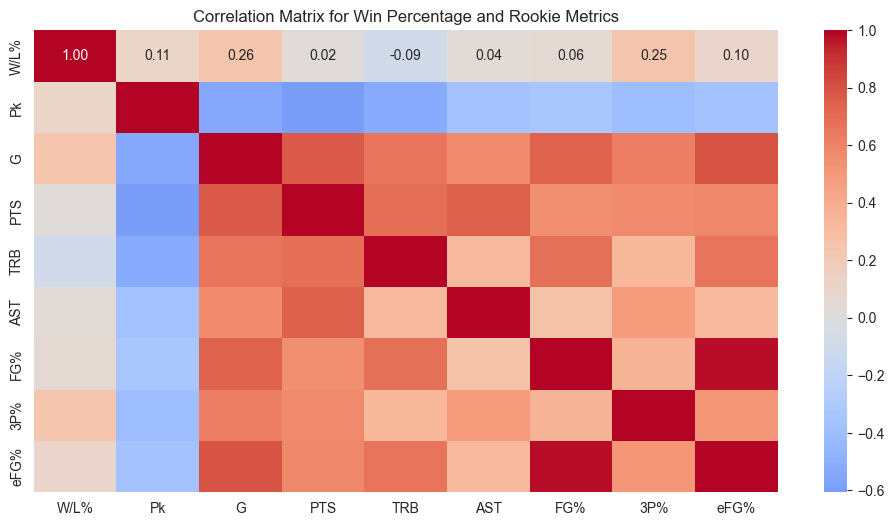

In [11]:
# Select relevant numeric features for correlation analysis
stats_cols = ['W/L%', 'Pk', 'G', 'PTS', 'TRB', 'AST', 'FG%', '3P%', 'eFG%']
stats_df = df[stats_cols].copy()
correlations = stats_df.corr()
print(correlations['W/L%'].sort_values(ascending=False))

plt.figure()
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Matrix for Win Percentage and Rookie Metrics')
plt.show()

### Insight
A correlation matrix helps identify which rookie statistics tend to appear in seasons with higher Bulls win percentages. This is exploratory and does not imply causation, but it highlights candidate performance indicators for further analysis.

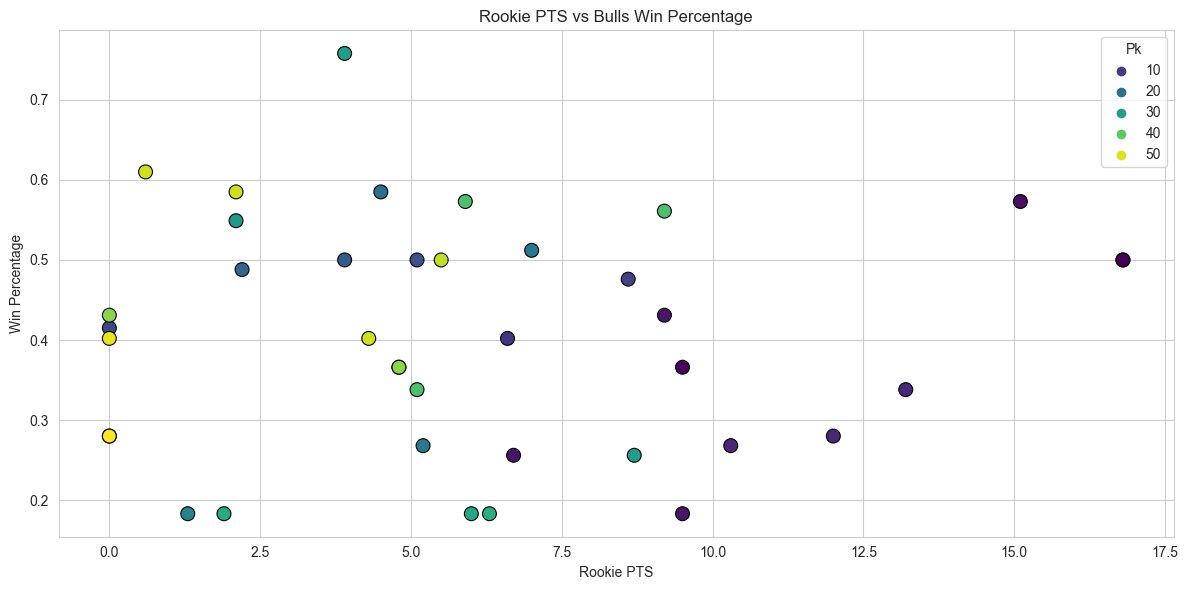

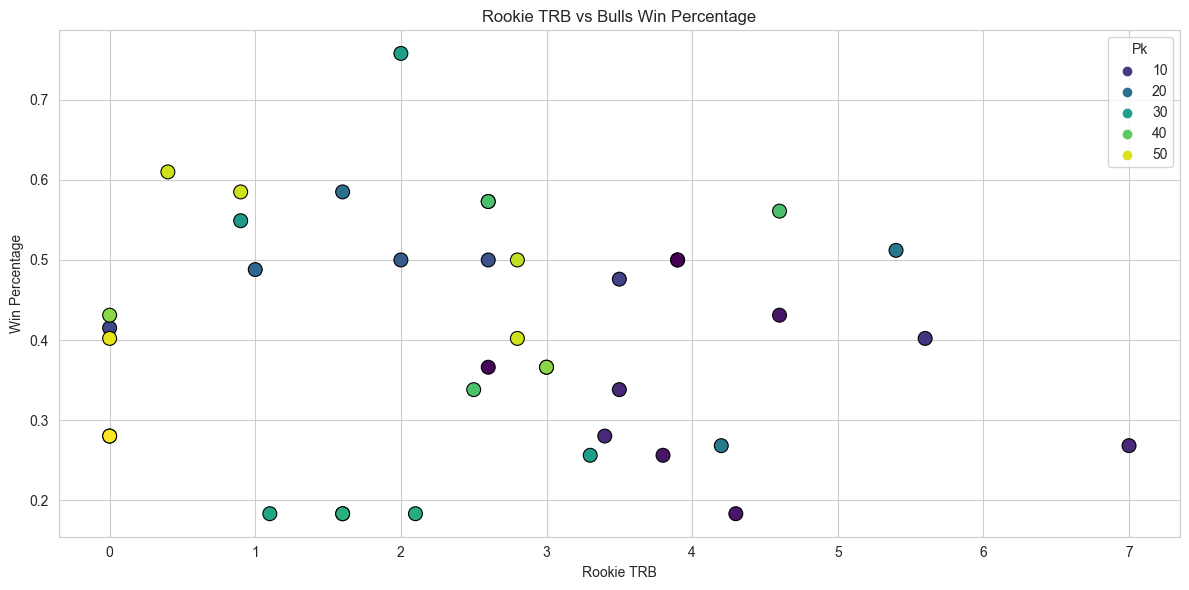

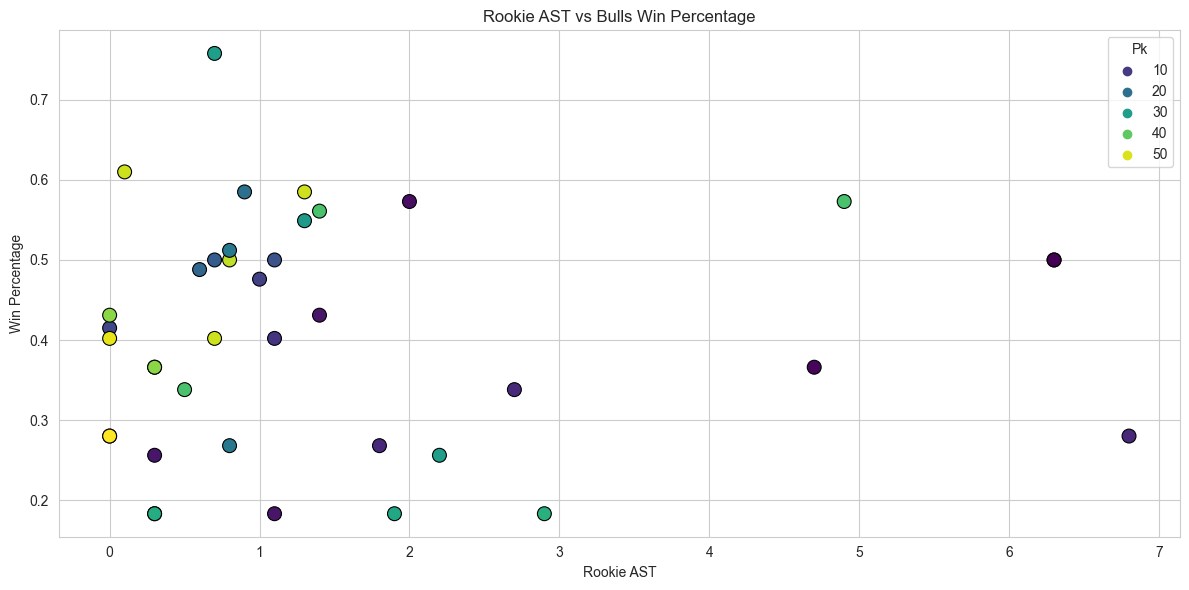

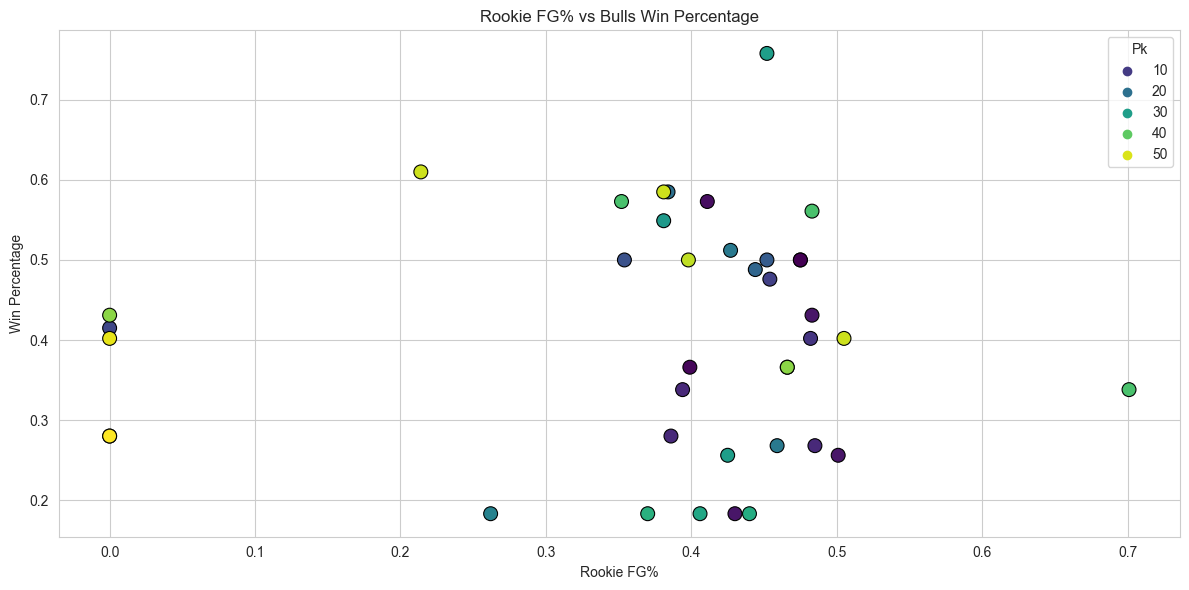

In [12]:
# Visualize key rookie metrics against win percentage
metrics = ['PTS', 'TRB', 'AST', 'FG%']
for metric in metrics:
    plt.figure()
    sns.scatterplot(data=df, x=metric, y='W/L%', hue='Pk', palette='viridis', edgecolor='black', s=100)
    plt.title(f'Rookie {metric} vs Bulls Win Percentage')
    plt.xlabel(f'Rookie {metric}')
    plt.ylabel('Win Percentage')
    plt.tight_layout()
    plt.show()

## Seasonal and historical context
We also examine how Bulls win percentage changed over time, and whether draft outcomes appear in stronger or weaker seasons.

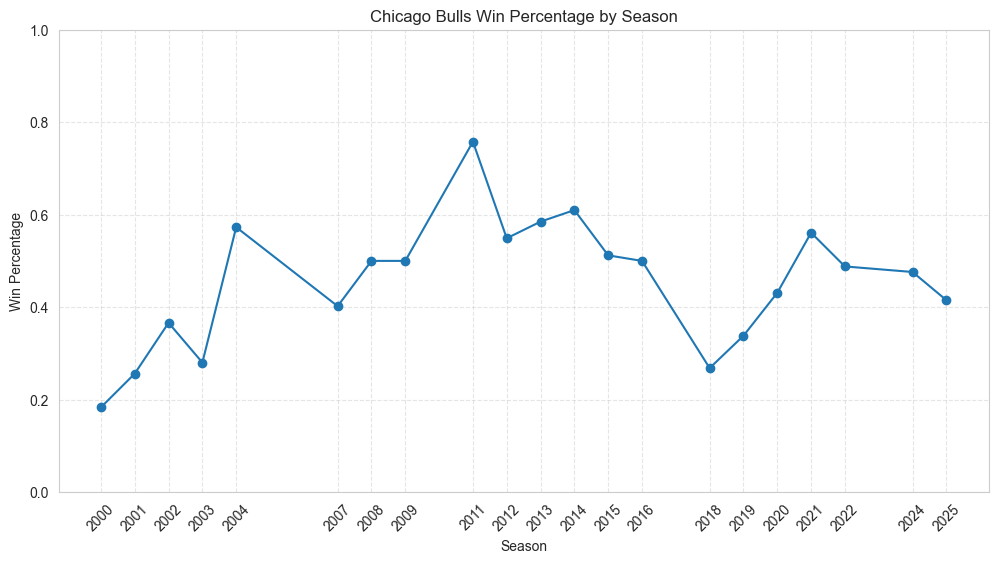

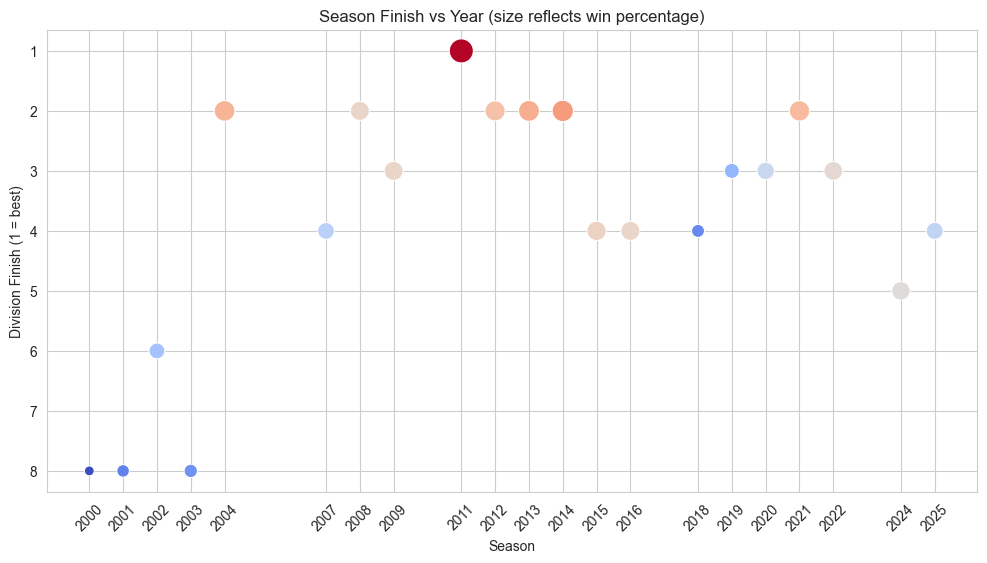

In [13]:
# Plot Bulls win percentage over seasons
plt.figure()
valid_seasons = df.drop_duplicates(subset='Season').sort_values('Season')
plt.plot(valid_seasons['Season'], valid_seasons['W/L%'], marker='o')
plt.title('Chicago Bulls Win Percentage by Season')
plt.xlabel('Season')
plt.ylabel('Win Percentage')
plt.xticks(valid_seasons['Season'], rotation=45)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Compare team finish and win percentage for context
plt.figure()
sns.scatterplot(data=valid_seasons, x='Season', y='Finish', size='W/L%', sizes=(50, 300), hue='W/L%', palette='coolwarm', legend=False)
plt.gca().invert_yaxis()
plt.title('Season Finish vs Year (size reflects win percentage)')
plt.ylabel('Division Finish (1 = best)')
plt.xticks(valid_seasons['Season'], rotation=45)
plt.show()

## Summary of findings
- Draft pick rank shows a modest relationship with win percentage; earlier picks are slightly more associated with stronger Bulls seasons.
- Rookie games played also have some positive alignment with team success, suggesting higher rookie availability may coincide with better outcomes.
- Rookie scoring and shooting efficiency are among the most meaningful performance metrics linked to team win percentage in this dataset.
- The Bulls dataset contains high season-to-season variability, so these exploratory results serve as a foundation for later modeling and hypothesis testing.